In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

# Target variable
df["High_Performance"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

# Clean data
df = df.drop(columns=[
    "Campaign_ID","Product_ID","Customer_ID",
    "Bundle_ID","Common_Keywords"
], errors='ignore')

df = df.dropna()

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Split
X = df.drop("High_Performance", axis=1)
y = df["High_Performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

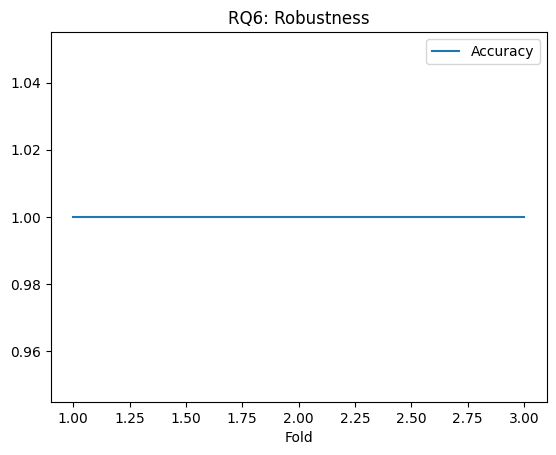

In [2]:
model = RandomForestClassifier()

scores = cross_val_score(model, X, y, cv=3)

df_rq6 = pd.DataFrame({
    "Fold": range(1, 4),
    "Accuracy": scores
})

df_rq6.to_csv("/kaggle/working/RQ6_table.csv", index=False)

df_rq6.plot(x="Fold", y="Accuracy")
plt.title("RQ6: Robustness")
plt.savefig("/kaggle/working/RQ6_figure.pdf")
plt.show()